In [1]:
%load_ext autoreload
%autoreload 2

## Plots

In [2]:
import json
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [5]:
import torch
# state_dict = torch.load(f'./results/4_architectures_with_taus/mnist20x20_arch0_l6_t3_ckpt.pth', map_location=torch.device('cpu'))
state_dict = torch.load(f'./results/3_neurons_with_taus/mnist20x20_k6000_l6_model_best.pth', map_location=torch.device('cpu'))

/rds/general/user/hn621/ephemeral/ipykernel_1771299/1774648073.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f'./results/3_neurons_with_taus/mn

In [12]:
json_objects = []
for exp_id in range(0, 6):
    fname = f"./results/1_neurons/00{520000+exp_id}.json"
    with open(fname, 'r', encoding='utf-8') as file:
        data = json.load(file)
        json_objects.append(data)

0.9785999763011932

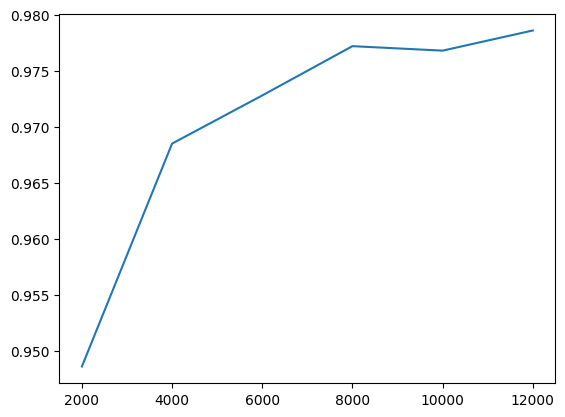

In [ ]:
accuracies = [max(js['test_acc_eval_mode']) for js in json_objects]
ks = [2000, 4000, 6000, 8000, 10000, 12000]
plt.plot(ks, accuracies)
max(accuracies)

0.9745999771356583

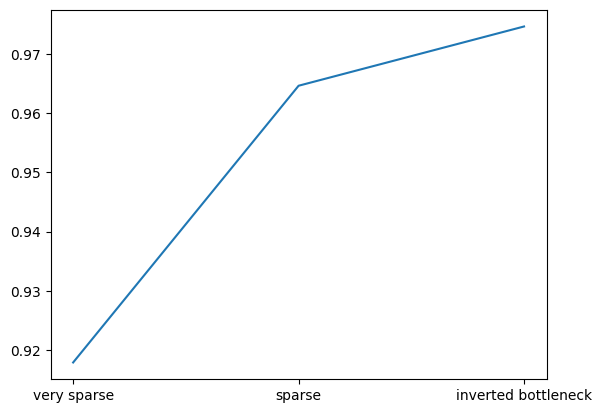

In [16]:
json_objects = []
for exp_id in range(0, 3):
    fname = f"./results/2_architectures/00{521000+exp_id}.json"
    with open(fname, 'r', encoding='utf-8') as file:
        data = json.load(file)
        json_objects.append(data)

accuracies = [max(js['test_acc_eval_mode']) for js in json_objects]
ks = ['very sparse', 'sparse', 'inverted bottleneck']
plt.plot(ks, accuracies)
max(accuracies)

## Evaluation

In [ ]:
import torch
from torch import nn
from difflogic import LogicLayer, MyLogicLayer, GroupSum

l = 6
k = 8000
kwargs = {'implementation': 'python_inference', 'device': 'cpu'}
model = nn.Sequential(
    nn.Flatten(),
    MyLogicLayer(400, k, **kwargs),
    *[MyLogicLayer(k, k, **kwargs) for i in range(l-1)],
    GroupSum(k=10, tau=10.0) # debug log: this is the evilness!!!
)
model

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fb60e59d5d0>>
Traceback (most recent call last):
  File "/rds/general/user/hn621/home/anaconda3/envs/molmo/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


ModuleNotFoundError: No module named 'difflogic'

In [115]:
model.state_dict().keys()

odict_keys(['1.weights', '1.indices_stored', '2.weights', '2.indices_stored', '3.weights', '3.indices_stored', '4.weights', '4.indices_stored', '5.weights', '5.indices_stored', '6.weights', '6.indices_stored'])

In [116]:
state_dict = torch.load(f'test_model_ckpt.pth', map_location=torch.device('cpu'))
# state_dict = torch.load(f'mnist20x20_k{k}_l{l}_model_final.pth', map_location=torch.device('cpu'))
# state_dict = torch.load(f'results/1/mnist20x20_k{k}_l{l}_model.pth', map_location=torch.device('cpu'))
# indices = torch.load(f'mnist20x20_k{k}_l{l}_indices.pth')
# state_dict = torch.load(f'best_model_full.pth', map_location=torch.device('cpu'))

In [ ]:
# state_dict.keys()

odict_keys(['1.weights', '1.indices_stored', '2.weights', '2.indices_stored', '3.weights', '3.indices_stored', '4.weights', '4.indices_stored', '5.weights', '5.indices_stored', '6.weights', '6.indices_stored'])

In [118]:
# state_dict = {k.replace('indices_stacked', 'indices'):v for k, v in state_dict.items()}
# state_dict = {k.replace('indices', 'indices_stored'):v for k, v in state_dict.items()}

In [ ]:
model.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
from experiments import mnist_dataset
import numpy as np
import math

def eval(model, loader, mode=False):
    orig_mode = model.training
    with torch.no_grad():
        model.train(mode=mode)
        res = np.mean(
            [
                (model(x.to('cpu').round()).argmax(-1) == y.to('cpu')).to(torch.float32).mean().item()
                for x, y in loader
            ]
        )
        model.train(mode=orig_mode)
    return res.item()

train_set = mnist_dataset.MNIST('./data-mnist', train=True, download=True, remove_border=True)
test_set = mnist_dataset.MNIST('./data-mnist', train=False, remove_border=True)

train_set_size = math.ceil((1) * len(train_set))
valid_set_size = len(train_set) - train_set_size
train_set, validation_set = torch.utils.data.random_split(train_set, [train_set_size, valid_set_size])

train_loader = torch.utils.data.DataLoader(train_set, batch_size=100, shuffle=True, pin_memory=True, drop_last=True, num_workers=4)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=100, shuffle=False, pin_memory=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, shuffle=False, pin_memory=True, drop_last=True)

In [122]:
eval(model, test_loader)

0.9370000034570694

## Heatmap

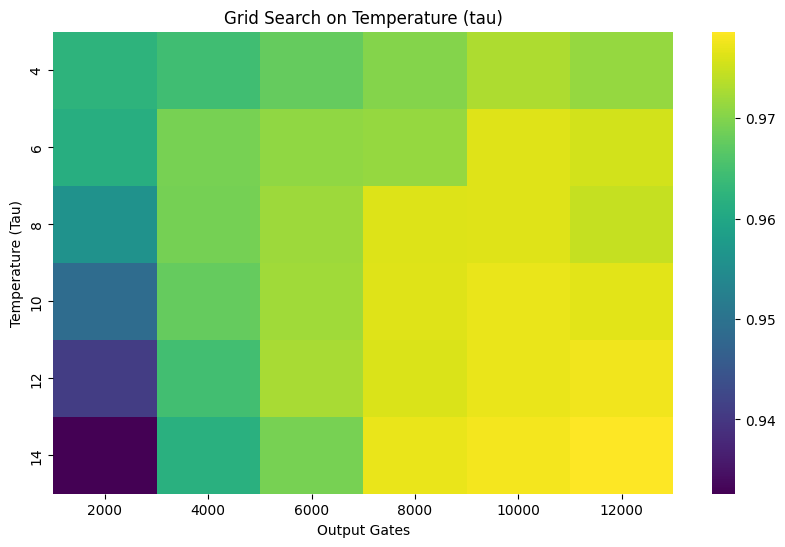

Heatmap generated and saved to: ./results/grid_search_heatmap.png


In [36]:
import os
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Parameters (should match the grid search settings) -----
# List of output neuron counts to try
K_NEURONS = [2000, 4000, 6000, 8000, 10000, 12000]
NUM_CLASSES = 10  # e.g., MNIST has 10 classes

# Fixed list of tau values used in the grid search (order should match the grid search)
TAU_VALUES = [4, 6, 8, 10, 12, 14]

# Base experiment ID (should be the same as used in the grid search script)
base_experiment_id = 525000

# Directory where the JSON log files are saved
RESULTS_DIR = "./results"

# Initialize results matrix: rows = tau values, columns = output_neurons/num_classes (ratio)
num_taus = len(TAU_VALUES)
num_configs = len(K_NEURONS)
results = np.zeros((num_taus, num_configs))

# Loop over each configuration (columns) and each tau value (rows)
for col, num_neurons in enumerate(K_NEURONS):
    output_ratio = num_neurons / NUM_CLASSES  # for x-axis labeling
    for row, tau in enumerate(TAU_VALUES):
        # Compute the experiment ID used for this configuration
        experiment_id = base_experiment_id + col * num_taus + row
        json_file_path = os.path.join(RESULTS_DIR, f"00{experiment_id}.json")
        
        try:
            with open(json_file_path, "r") as jf:
                log_data = json.load(jf)
            # Extract the accuracy from the JSON
            final_accuracy = float(max(log_data["test_acc_eval_mode"]))
        except Exception as e:
            print(f"Error reading {json_file_path}: {e}")
            final_accuracy = 0.0
        
        results[row, col] = final_accuracy

x_labels = [f"{k}" for k in K_NEURONS]
y_labels = [str(t) for t in TAU_VALUES]

# Plot the heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(results, annot=False, fmt=".1f", xticklabels=x_labels, yticklabels=y_labels, cmap="viridis")
ax.set_xlabel("Output Gates")
ax.set_ylabel("Temperature (Tau)")
ax.set_title("Grid Search on Temperature (tau)")
heatmap_path = os.path.join(RESULTS_DIR, "grid_search_heatmap.png")
plt.savefig(heatmap_path)
plt.show()

print(f"Heatmap generated and saved to: {heatmap_path}")

Fitted line: tau = 0.5542 * x + -3.4836


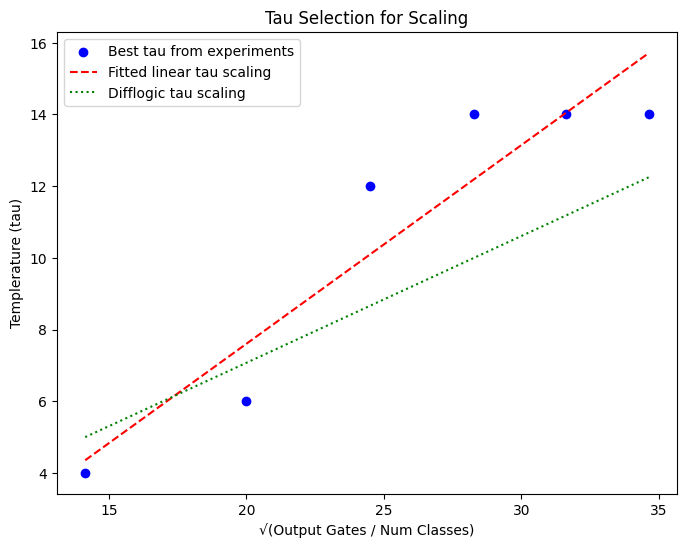

Linearity plot saved to: ./results/linearity_plot.png


In [38]:
import os
import json
import math
import numpy as np
import matplotlib.pyplot as plt

# Base experiment ID (should be the same as in your grid search script)
base_experiment_id = 525000

# Directory where the JSON log files are saved
RESULTS_DIR = "./results"

# Number of tau values and network configurations
num_taus = len(TAU_VALUES)
num_configs = len(K_NEURONS)

# Initialize a results matrix: rows: tau values, columns: different output neuron configs
results = np.zeros((num_taus, num_configs))

# Loop over each configuration (column) and each tau value (row)
for col, num_neurons in enumerate(K_NEURONS):
    for row, tau in enumerate(TAU_VALUES):
        experiment_id = base_experiment_id + col * num_taus + row
        json_file_path = os.path.join(RESULTS_DIR, f"00{experiment_id}.json")
        try:
            with open(json_file_path, "r") as jf:
                log_data = json.load(jf)
            final_accuracy = float(log_data["test_acc_eval_mode_"])
        except Exception as e:
            print(f"Error reading {json_file_path}: {e}")
            final_accuracy = 0.0
        results[row, col] = final_accuracy

# For each configuration (each column), find the tau that gave the highest accuracy.
best_tau = []
for col in range(num_configs):
    # Get the index (row) of the maximum accuracy in this column.
    best_index = np.argmax(results[:, col])
    best_tau_value = TAU_VALUES[best_index]
    best_tau.append(best_tau_value)

best_tau = np.array(best_tau)

# Compute the x-axis values: x = sqrt(output_neurons / NUM_CLASSES)
x_values = np.array([math.sqrt(k / NUM_CLASSES) for k in K_NEURONS])

# For reference, compute what would be the correct tau to use in difflogic
ideal_tau = 0.3536 * x_values

# fit a linear regression to (x_values, best_tau)
coeffs = np.polyfit(x_values, best_tau, 1)
fit_line = np.poly1d(coeffs)

print(f"Fitted line: tau = {coeffs[0]:.4f} * x + {coeffs[1]:.4f}")

# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(x_values, best_tau, color='blue', label="Best tau from experiments")
plt.plot(x_values, fit_line(x_values), color='red', linestyle='--', label="Fitted linear tau scaling")
plt.plot(x_values, ideal_tau, color='green', linestyle=':', label="Difflogic tau scaling")
plt.xlabel("√(Output Gates / Num Classes)")
plt.ylabel("Templerature (tau)")
plt.title("Tau Selection for Scaling")
plt.legend()
plot_path = os.path.join(RESULTS_DIR, "linearity_plot.png")
plt.savefig(plot_path)
plt.show()

print(f"Linearity plot saved to: {plot_path}")

In [42]:
np.max(results)

0.9785999780893326

In [43]:
results

array([[0.96229998, 0.96449998, 0.96769998, 0.97009998, 0.97299998,
        0.97139998],
       [0.96139998, 0.96909998, 0.97089998, 0.97139998, 0.97639998,
        0.97549998],
       [0.95609998, 0.96899998, 0.97179998, 0.97619997, 0.97639998,
        0.97459998],
       [0.94859998, 0.96769998, 0.97199998, 0.97639998, 0.97699997,
        0.97649998],
       [0.94079998, 0.96469998, 0.97249998, 0.97599998, 0.97699997,
        0.97769998],
       [0.93259998, 0.96179998, 0.96909998, 0.97709998, 0.97779998,
        0.97859998]])